In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Import feral from THIS source repo, not the stale 0.4.0 installed in the pixi env.
# Must run before any `import feral`. If feral was already imported, RESTART THE KERNEL
# and run this cell first (Kernel -> Restart, then run top to bottom).
import torch

import sys
sys.path.insert(0, "/home/dengd3@hhmi.org/feral")

import feral.dataset
assert hasattr(feral.dataset, "ContrastiveVideoDataset"), \
    f"Wrong feral loaded: {feral.dataset.__file__} -- restart the kernel and run this cell first"
print("feral.dataset ->", feral.dataset.__file__)

feral.dataset -> /home/dengd3@hhmi.org/feral/feral/dataset.py


In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

len(ds) = 32
{'vid1': torch.Size([64, 3, 224, 224]), 'vid2': torch.Size([64, 3, 224, 224]), 'vid3': torch.Size([64, 3, 224, 224])}


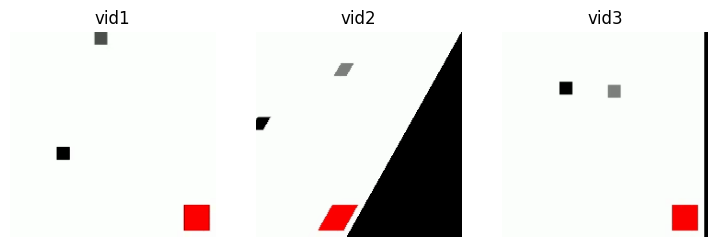

In [7]:
# Making the Dataset

from feral.dataset import ContrastiveVideoDataset
import matplotlib.pyplot as plt

prefix = "/home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/videos"                 # dir holding the videos
video_paths = ["synthetic_04.mp4", "synthetic_05.mp4"]            # filenames relative to prefix

ds = ContrastiveVideoDataset(
    video_paths=video_paths,
    prefix=prefix,
    num_samples=32,
    chunk_length=64, chunk_step=1,
    resize_to=224, resize_style="square",
    do_aa=True, seed=0,
)

print("len(ds) =", len(ds))

item = ds[0]
print({k: v.shape for k, v in item.items()})   # each (64, 3, 224, 224)

# undo the vjepa Normalize so frames display with natural colors
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show(frame):
    return (frame * std + mean).permute(1, 2, 0).clamp(0, 1)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for a, k in zip(ax, ("vid1", "vid2", "vid3")):
    a.imshow(show(item[k][0]))          # first frame of each clip
    a.set_title(k); a.axis("off")
plt.show()
# vid1 & vid2: same clip with offset, different augmentation. vid3: a different clip.

In [8]:
# ---- verify FeralModel.forward_features returns feature vectors, not labels ----
import torch
from feral.modeling import build_model
from feral.cli import _load_default_config

cfg = _load_default_config()
cfg['model']['pretrained'] = False        # skip the weight download for a shape check
cfg['training']['compile'] = False        # avoid torch.compile friction while prototyping

model, _ = build_model(cfg, num_classes=2, device=device, with_ema=False)
model.eval()

T = cfg['data']['chunk_length']           # 64
R = cfg['data']['resize_to']              # 256
x = torch.randn(2, T, 3, R, R, device=device)

with torch.no_grad():
    feats  = model.forward_features(x)    # NEW: per-frame feature vectors
    logits = model(x)                     # unchanged: class logits still work
    hello = model.forward(x)

D = model.backbone.hidden_dim
print("feats :", tuple(feats.shape),  "expected", (2, cfg['predict_per_item'], D))
print("logits:", tuple(logits.shape), "expected", (2 * cfg['predict_per_item'], 2))
assert feats.shape == (2, cfg['predict_per_item'], D)
print("OK — model returns (B, 64, D) features")

# For a *semantic* check (vid1~vid2 closer than vid1~vid3), set pretrained=True
# above, build a ContrastiveVideoDataset at resize_to=R, batch a triplet through
# forward_features, mean-pool over frames, and compare cosine similarities.

/home/dengd3@hhmi.org/feral_project/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


feats : (2, 64, 1024) expected (2, 64, 1024)
logits: (128, 2) expected (128, 2)
OK — model returns (B, 64, D) features


In [20]:
# ---- run contrastive pretraining in the notebook (mirrors train.py phase 1) ----
from torch.utils.data import DataLoader
from feral.dataset import ContrastiveVideoDataset, collate_fn_contrastive
from feral.modeling import build_model, build_contrastive_objects
from feral.loops import train_contrastive_epoch
from feral.utils import save_model
from feral.cli import _load_default_config

cfg = _load_default_config()
cfg['model']['pretrained'] = True                 # start from the VJEPA backbone
cfg['training']['compile'] = False
cfg['training']['contrastive_epochs'] = 5         # bump up for a real run
cfg['training']['contrastive_num_samples'] = 128  # triplets drawn per epoch
cfg['training']['train_bs'] = 2                   # 3 clips/item -> keep small (VRAM)
R = cfg['data']['resize_to']                      # 256, matches the backbone

ds = ContrastiveVideoDataset(
    video_paths=video_paths, prefix=prefix,
    num_samples=cfg['training']['contrastive_num_samples'],
    chunk_length=cfg['data']['chunk_length'], chunk_step=cfg['data']['chunk_step'],
    resize_to=R, resize_style=cfg['data']['resize_style'], do_aa=True, seed=0,
)
loader = DataLoader(ds, batch_size=cfg['training']['train_bs'], shuffle=True,
                    drop_last=True, collate_fn=collate_fn_contrastive)

model, _ = build_model(cfg, num_classes=2, device=device, with_ema=False)
opt, sched = build_contrastive_objects(cfg, model, loader)   # AdamW + cosine schedule

for epoch in range(cfg['training']['contrastive_epochs']):
    ds.resample()                                  # fresh triplets each epoch
    avg = train_contrastive_epoch(               # per-epoch tqdm bar; log_fn=None (no wandb)
        model, loader, opt, sched, device=device,
        margin=cfg['training']['contrastive_margin'],
    )
    print(f"epoch {epoch}: contrastive loss {avg:.4f}")

# save so the extract-embeddings / finetune paths can reuse the trained encoder
save_model(model, "/tmp/nb_pretrained.pt",
           {'class_names': {0: 'a', 1: 'b'}, 'is_multilabel': False, 'cfg': cfg})
print("saved -> /tmp/nb_pretrained.pt")

# `model` + `cfg` now hold the CONTRASTIVELY-TRAINED encoder. Re-run the extract
# cell + viz cell below to compare its embeddings vs the pretrained baseline.
# Compute: 3 ViT-L forwards/step; 128 samples / bs2 = 64 steps x 3 epochs ~ 200
# steps (a few min). Scale num_samples/epochs up for a serious run; drop train_bs
# to 1 or set cfg['model']['gradient_checkpointing']=True if you hit OOM.

14:54:44 httpx INFO: HTTP Request: HEAD https://huggingface.co/facebook/vjepa2-vitl-fpc32-256-diving48/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:54:44 httpx INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/vjepa2-vitl-fpc32-256-diving48/71ae2a8b1ff5a297aeeaae9b5e64c7a2e5e6a633/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 587/587 [00:00<00:00, 12520.12it/s]
VJEPA2Model LOAD REPORT from: facebook/vjepa2-vitl-fpc32-256-diving48
Key                                                              | Status     |  | 
-----------------------------------------------------------------+------------+--+-
pooler.self_attention_layers.{0, 1, 2}.self_attn.v_

epoch 0: contrastive loss 0.4272


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [01:10<00:00,  1.10s/it]


epoch 1: contrastive loss 0.2149


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [01:10<00:00,  1.11s/it]


epoch 2: contrastive loss 0.2911


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [01:10<00:00,  1.10s/it]


epoch 3: contrastive loss 0.1641


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [01:11<00:00,  1.12s/it]


epoch 4: contrastive loss 0.2456
saved -> /tmp/nb_pretrained.pt


In [22]:
# ---- extract one embedding per chunk over the whole video folder ----
from feral.embeddings import extract_embeddings_folder

# reuses `model` + `cfg` from the cells above (pretrained encoder, resize_to=256)
emb, ids = extract_embeddings_folder(
    model, cfg, prefix, batch_size=4, num_workers=2,
    save_path="/tmp/feral_emb.npz",
)
print("emb:", tuple(emb.shape), "| D:", model.backbone.hidden_dim, "| n_chunks:", len(ids))
print("first ids (file, start_frame):", ids[:3])

15:06:48 feral.inference_folder INFO: Found 18 video files out of 18 files in /home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/videos
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143/143 [00:48<00:00,  2.94it/s]

emb: (571, 1024) | D: 1024 | n_chunks: 571
first ids (file, start_frame): [('synthetic_00.mp4', 0), ('synthetic_00.mp4', 32), ('synthetic_00.mp4', 64)]


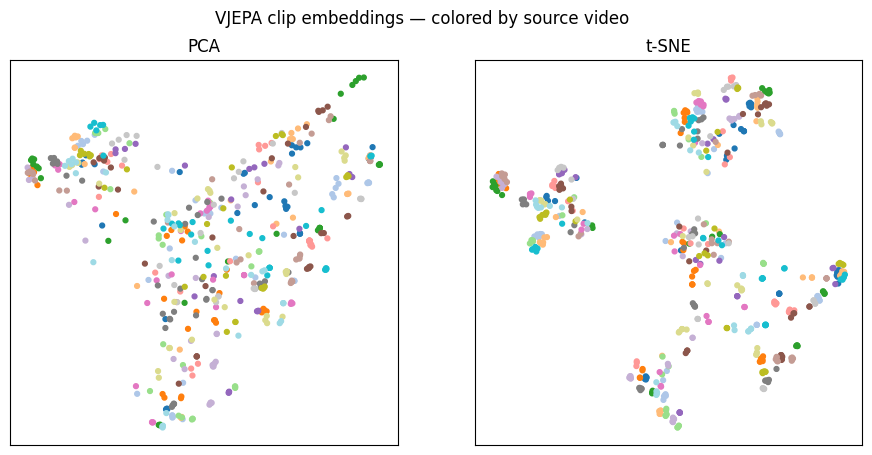

In [23]:
# 2-D projections of the embeddings (PCA + t-SNE), colored by source video
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X = emb.numpy()
files = np.array([f for f, _ in ids])
codes = {f: i for i, f in enumerate(sorted(set(files)))}
c = [codes[f] for f in files]

pca = PCA(n_components=2).fit_transform(X)
tsne = TSNE(n_components=2, perplexity=min(30, max(2, len(X) // 3)),
            init="pca").fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for a, proj, name in ((ax[0], pca, "PCA"), (ax[1], tsne, "t-SNE")):
    a.scatter(proj[:, 0], proj[:, 1], c=c, cmap="tab20", s=12)
    a.set_title(name); a.set_xticks([]); a.set_yticks([])
fig.suptitle("VJEPA clip embeddings — colored by source video")
plt.show()
# Each point = one 64-frame chunk. Look for structure (clips clustering by
# video / content). This is the baseline before any contrastive training.

/home/dengd3@hhmi.org/feral_project/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dengd3@hhmi.org/feral_project/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


6 behavior clusters | 22.1% noise


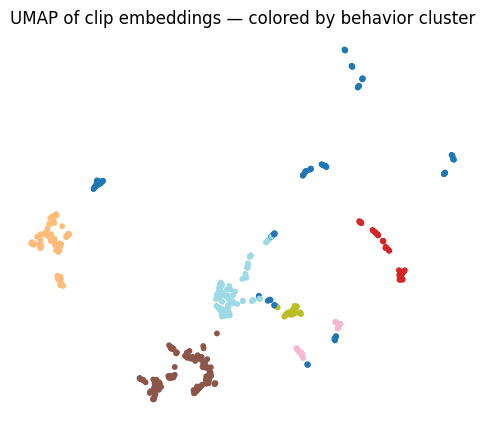

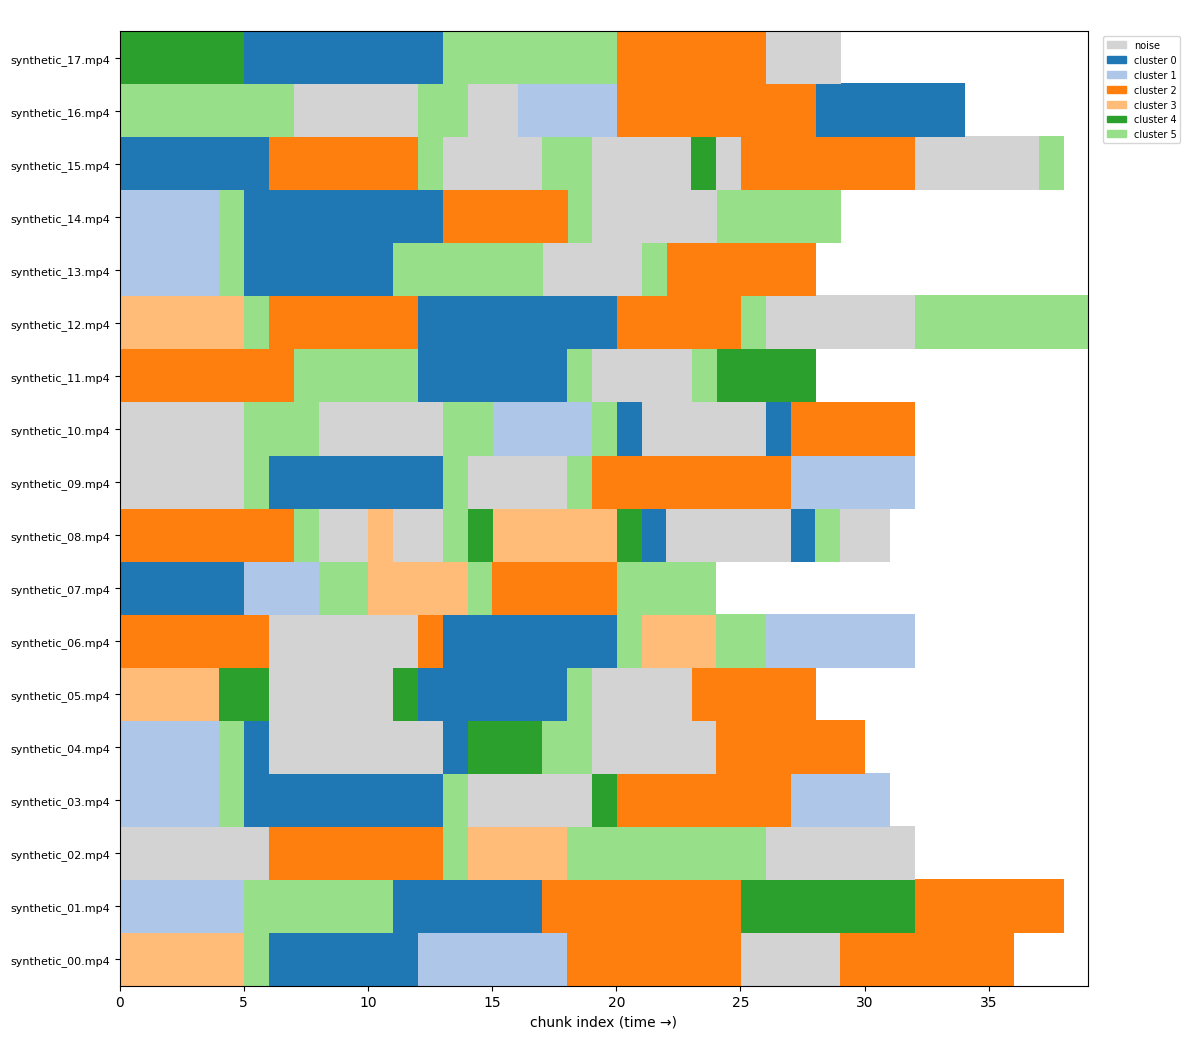

In [24]:
# ---- unsupervised behavior discovery: UMAP -> HDBSCAN -> ethogram ----
# reuses `emb` + `ids` from the extract cell above
from feral.behavior import cluster_embeddings, behavior_ethogram

labels, emb2d = cluster_embeddings(emb, min_cluster_size=25)
n_clusters = len(set(labels.tolist())) - (1 if -1 in labels else 0)
print(f"{n_clusters} behavior clusters | {(labels == -1).mean():.1%} noise")

# UMAP colored by discovered behavior cluster
plt.figure(figsize=(6, 5))
plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, cmap="tab20", s=10)
plt.title("UMAP of clip embeddings — colored by behavior cluster")
plt.axis("off"); plt.show()

# per-video ethogram (one row per video, chunks in time, colored by cluster)
behavior_ethogram(ids, labels)
plt.show()

# To compare PRETRAINED vs CONTRASTIVELY-TRAINED: run the extract cell with each
# `model` (baseline backbone vs the trained one from the pretraining cell), then
# re-run this cell and eyeball whether the trained encoder gives cleaner, more
# temporally-contiguous ethogram bands and better-separated UMAP clusters.

In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import defaultdict
from pathlib import Path

with open("/home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/labels_singlelabel.json") as f:
    labels_single_json = json.load(f)

SINGLE_CLASS_NAMES = {int(k): v for k, v in labels_single_json["class_names"].items()}
print(SINGLE_CLASS_NAMES)

with open("/home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/labels_multilabel.json") as f:
    labels_multi_json = json.load(f)

MULTI_CLASS_NAMES = {int(k): v for k, v in labels_multi_json["class_names"].items()}
print(MULTI_CLASS_NAMES)

{0: 'other', 1: 'copulation', 2: 'eating', 3: 'sleeping', 4: 'playing'}
{0: 'mouse_a_eating', 1: 'mouse_a_sleeping', 2: 'mouse_b_eating', 3: 'mouse_b_sleeping', 4: 'copulation', 5: 'playing'}


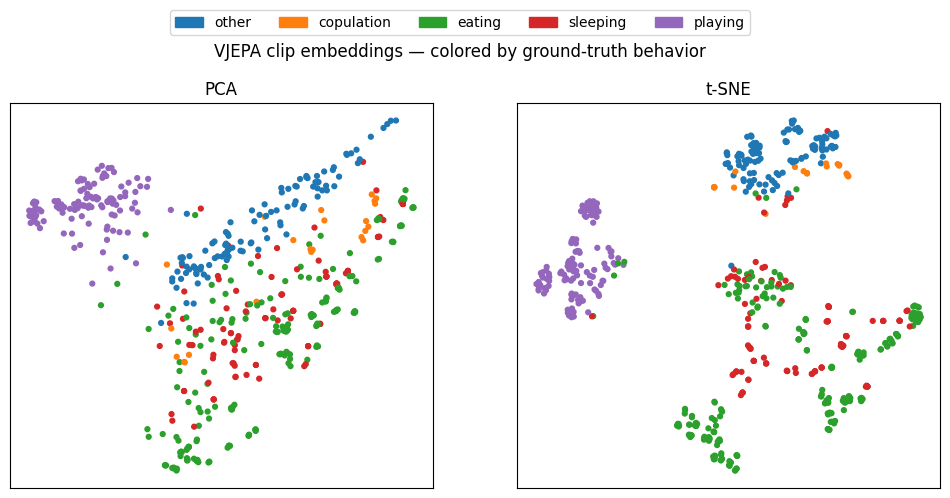

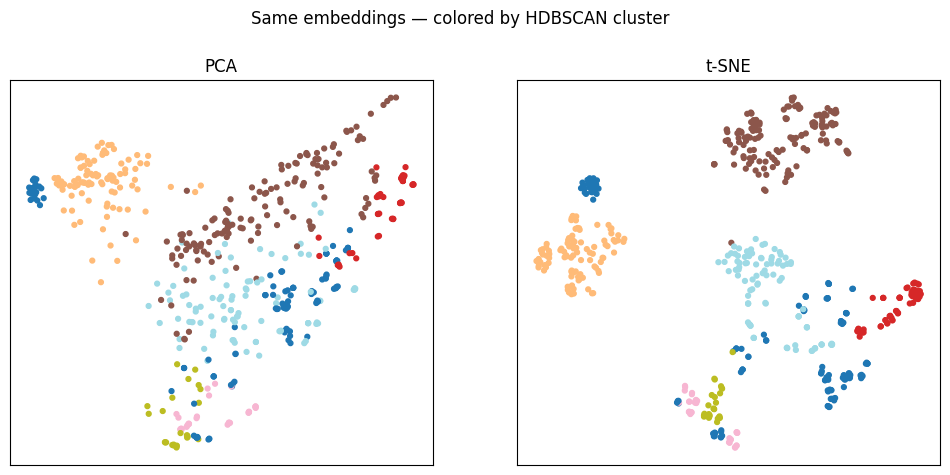

In [32]:
# 2d projections of the embeddings, colored by ground truth class
import numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# reuse `chunk_gt_label` / `frame_labels` / `class_names` from the evaluation cell
X = emb.numpy() if hasattr(emb, "numpy") else np.asarray(emb)
gt = np.array([chunk_gt_label(fn, start) for fn, start in ids])

pca = PCA(n_components=2).fit_transform(X)
tsne = TSNE(n_components=2, perplexity=min(30, max(2, len(X) // 3)),
            init="pca").fit_transform(X)

uniq_classes = sorted(set(gt.tolist()))
cmap = plt.get_cmap("tab10")
class_to_color = {c: cmap(i % cmap.N) for i, c in enumerate(uniq_classes)}
point_colors = [class_to_color[c] for c in gt]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, proj, name in ((ax[0], pca, "PCA"), (ax[1], tsne, "t-SNE")):
    a.scatter(proj[:, 0], proj[:, 1], c=point_colors, s=12)
    a.set_title(name); a.set_xticks([]); a.set_yticks([])

handles = [mpatches.Patch(color=class_to_color[c], label=class_names[c]) for c in uniq_classes]
fig.legend(handles=handles, loc="upper center", ncol=len(uniq_classes), bbox_to_anchor=(0.5, 1.08))
fig.suptitle("VJEPA clip embeddings — colored by ground-truth behavior", y=1.0)
plt.show()

# If you want a quick eyeball comparison, also color by discovered cluster
# (only meaningful after you've run cluster_embeddings and have `labels`):
if 'labels' in dir():
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    for a, proj, name in ((ax[0], pca, "PCA"), (ax[1], tsne, "t-SNE")):
        a.scatter(proj[:, 0], proj[:, 1], c=labels, cmap="tab20", s=12)
        a.set_title(name); a.set_xticks([]); a.set_yticks([])
    fig.suptitle("Same embeddings — colored by HDBSCAN cluster", y=1.02)
    plt.show()

NMI: 0.627  |  ARI: 0.514  |  noise: 22.1%
Best-match cluster purity/accuracy: 55.1%
Cluster -> best-matching class: {2: 'other', 3: 'copulation', 1: 'eating', 4: 'sleeping', 0: 'playing'}


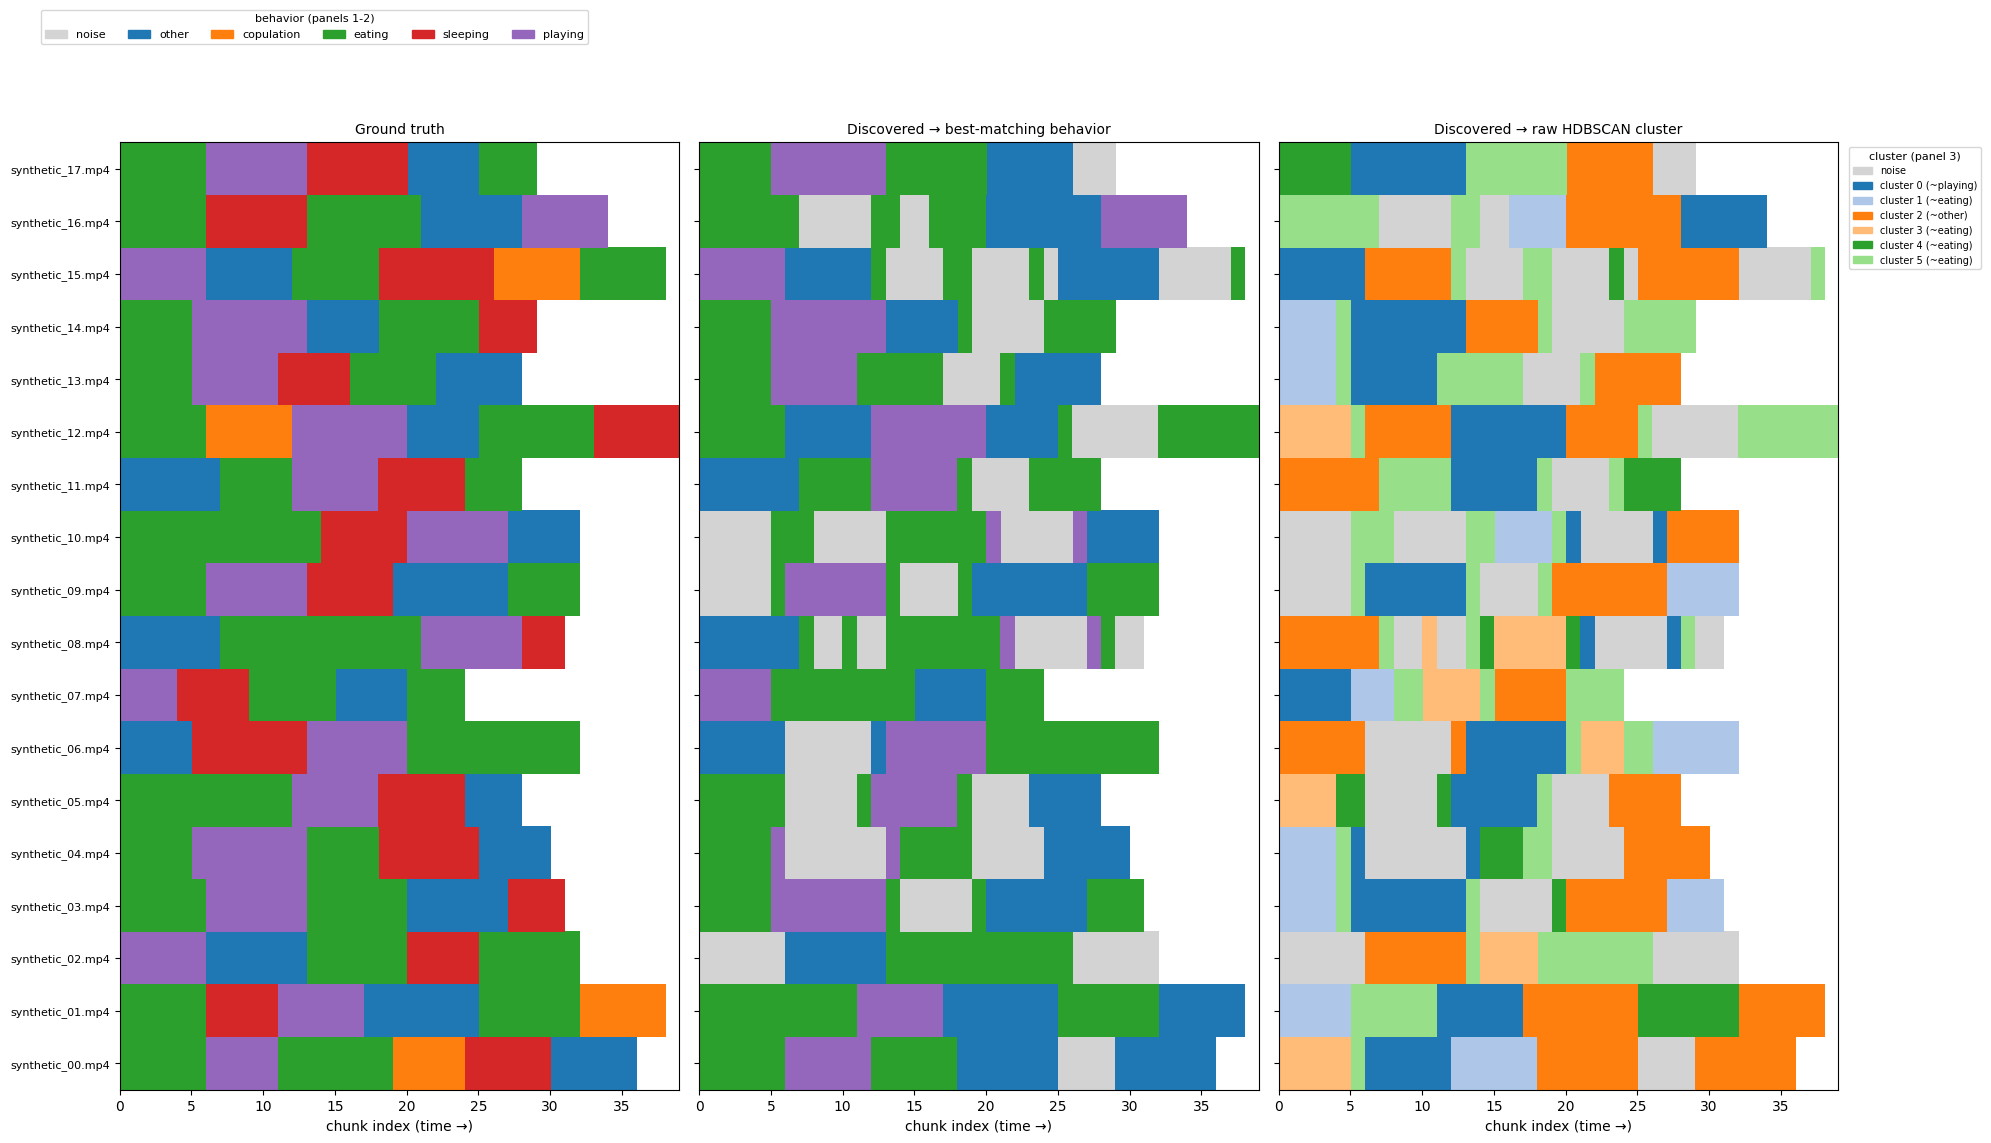

In [34]:
# ---- evaluate discovered clusters against the synthetic ground-truth labels ----
import json
import numpy as np
from collections import Counter
from sklearn.metrics import (
    normalized_mutual_info_score, adjusted_rand_score,
    confusion_matrix
)
from scipy.optimize import linear_sum_assignment

# Path to the labels JSON that ships with synthetic dataset (single-label version)
LABELS_JSON_PATH = "/home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/labels_singlelabel.json"
with open(LABELS_JSON_PATH) as f:
    labels_json = json.load(f)

class_names = {int(k): v for k, v in labels_json["class_names"].items()}
frame_labels = labels_json["labels"]  # filename -> list[int], one label per frame

CHUNK_SPAN = 64  # frames per chunk, matches extract_embeddings_folder / dataset span

def chunk_gt_label(fn, start):
    """Majority ground-truth class over the chunk's frame span."""
    seq = frame_labels[fn][start:start + CHUNK_SPAN]
    return Counter(seq).most_common(1)[0][0] # finds most common frame label in a chunk

gt = np.array([chunk_gt_label(fn, start) for fn, start in ids]) # true ground truth class per chunk
pred = np.asarray(labels)  # HDBSCAN cluster ids, -1 = noise

# Optionally exclude noise chunks from scoring (or keep them as their own "cluster")
mask = pred != -1
gt_eval, pred_eval = gt[mask], pred[mask]

nmi = normalized_mutual_info_score(gt_eval, pred_eval) # how much knowing the cluster tells you about the true class
ari = adjusted_rand_score(gt_eval, pred_eval) # agreement on which pairs of chunks Land together, corrected for chance
print(f"NMI: {nmi:.3f}  |  ARI: {ari:.3f}  |  noise: {(~mask).mean():.1%}")

# ---- Hungarian-matched purity/accuracy + confusion matrix ----
# Gets a "% correct" number and a name for each cluster; optimally pairs each cluster with a ground-truth class
uniq_pred = sorted(set(pred_eval.tolist()))
uniq_gt = sorted(set(gt_eval.tolist()))
cm = confusion_matrix(gt_eval, pred_eval, labels=uniq_gt)  # rows=gt, cols=pred(sorted)
# pad/reindex cm to align with uniq_pred ordering from confusion_matrix's own label sort

pred_sorted = sorted(uniq_pred)
row_ind, col_ind = linear_sum_assignment(-cm)  # maximize matches
matched_correct = cm[row_ind, col_ind].sum()
cluster_acc = matched_correct / len(gt_eval)
print(f"Best-match cluster purity/accuracy: {cluster_acc:.1%}")

# Finds the cluster-class pairing that maximizes total correct assignments
cluster_to_class = {pred_sorted[c]: class_names[uniq_gt[r]] for r, c in zip(row_ind, col_ind)}
print("Cluster -> best-matching class:", cluster_to_class)

# ---- ethograms: ground truth vs discovered(named) vs discovered(raw clusters), side by side ----
# Panels 1-2 share a behavior-name color scheme; panel 3 colors by raw HDBSCAN cluster id so
# every cluster is visible (incl. behaviors that never win a cluster's majority vote, e.g.
# sleeping/copulation get outvoted inside eating-/other-dominated clusters).
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# discovered cluster -> ground-truth behavior id (majority vote over its chunks); noise (-1) stays -1
cluster_gt = {cl: Counter(gt[pred == cl]).most_common(1)[0][0]
              for cl in set(pred.tolist()) if cl != -1}
pred_named = np.array([cluster_gt.get(cl, -1) for cl in pred])  # per-chunk behavior id

# color scheme A: one color per behavior (shared by panels 1 & 2); light gray = noise/unmatched
base = plt.get_cmap("tab10")
class_color = {c: base(i % base.N) for i, c in enumerate(sorted(class_names))}
class_color[-1] = (0.83, 0.83, 0.83, 1.0)

# color scheme B: one color per raw HDBSCAN cluster (panel 3); light gray = noise
clusters = sorted(set(pred.tolist()))
ctab = plt.get_cmap("tab20")
cluster_color = {cl: ctab(j % ctab.N) for j, cl in enumerate(c for c in clusters if c != -1)}
cluster_color[-1] = (0.83, 0.83, 0.83, 1.0)

videos = sorted(set(fn for fn, _ in ids))

def _ethogram(ax, chunk_val, color, title):
    """One row per video, chunks in temporal order, each cell colored via `color[val]`."""
    rows = defaultdict(list)
    for (fn, start), v in zip(ids, chunk_val):
        rows[fn].append((int(start), int(v)))
    for i, fn in enumerate(videos):
        seq = [v for _, v in sorted(rows.get(fn, []))]
        strip = np.array([color[v] for v in seq])[None, :, :]  # (1, N, RGBA)
        ax.imshow(strip, aspect="auto", extent=[0, len(seq), i, i + 1],
                  interpolation="nearest")
    ax.set_ylim(0, len(videos))
    ax.set_xlim(0, max(len(rows.get(fn, [])) for fn in videos))
    ax.set_yticks([i + 0.5 for i in range(len(videos))])
    ax.set_yticklabels(videos, fontsize=8)
    ax.set_xlabel("chunk index (time →)")
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 3, figsize=(20, 1.4 + 0.5 * len(videos)), sharey=True)
_ethogram(axes[0], gt,         class_color,   "Ground truth")
_ethogram(axes[1], pred_named, class_color,   "Discovered → best-matching behavior")
_ethogram(axes[2], pred,       cluster_color, "Discovered → raw HDBSCAN cluster")

# behavior-name legend for panels 1 & 2 (shared color scheme A)
present = sorted(set(gt.tolist()) | set(pred_named.tolist()))
beh_handles = [mpatches.Patch(color=class_color[c],
                              label=("noise" if c == -1 else class_names[c]))
               for c in present]
fig.legend(handles=beh_handles, loc="upper left", bbox_to_anchor=(0.02, 1.10),
           ncol=min(len(beh_handles), 6), fontsize=8,
           title="behavior (panels 1-2)", title_fontsize=8)

# raw-cluster legend for panel 3, each entry annotated with the cluster's dominant behavior
cl_handles = [mpatches.Patch(color=cluster_color[cl],
                             label=("noise" if cl == -1
                                    else f"cluster {cl} (~{class_names[cluster_gt[cl]]})"))
              for cl in clusters]
axes[2].legend(handles=cl_handles, bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=7, title="cluster (panel 3)", title_fontsize=8)

fig.tight_layout()
plt.show()